In [29]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def insert_bedGraph_into_HDF5(run_id:str, base_data_directory:str, rep_file:str, rep_name:str, all_chr_names:list, tab_filtL_hdf5, dt):

    #try:
    #    tab = pd.read_table(rep_file, header=None, skiprows=1)
    #except:
    #    tab = pd.read_table(base_data_directory+run_id+'/'+rep_file, header=None, skiprows=1)
    tab = pd.read_table(base_data_directory+run_id+'/'+rep_file, header=None, skiprows=1)
    tab.columns = ['chr','coord0','coord1','coverage','meth_reads','unmeth_reads']
    read_num = tab.loc[:,'meth_reads'].add(tab.loc[:,'unmeth_reads']);
    tab_filt = tab.where(tab.loc[:,'chr'].isin(all_chr_names)).dropna();

    shape_param = (tab_filt.shape[0], tab_filt.shape[1]-1)
    dset = tab_filtL_hdf5.create_group(rep_name)
    dset = tab_filtL_hdf5.create_dataset(rep_name+'/'+tab_filt.columns[0], shape=(shape_param[0],), dtype=dt, compression='gzip')
    dset = tab_filtL_hdf5.create_dataset(rep_name+'/data', shape=shape_param, dtype='i', compression='gzip')

    tab_filtL_hdf5[rep_name+'/'+tab_filt.columns[0]][...]=tab_filt.iloc[:,0].values.astype(dt)
    tab_filtL_hdf5[rep_name+'/data'][...]=tab_filt.iloc[:,1:].values

In [3]:
def insert_bedGraph_into_HDF5(bedGraph_file:str, rep_name:str, all_chr_names:list, tab_filtL_hdf5, dt):

    #try:
    #    tab = pd.read_table(rep_file, header=None, skiprows=1)
    #except:
    #    tab = pd.read_table(base_data_directory+run_id+'/'+rep_file, header=None, skiprows=1)
    tab = pd.read_table(bedGraph_file, header=None, skiprows=1)
    tab.columns = ['chr','coord0','coord1','coverage','meth_reads','unmeth_reads']
    read_num = tab.loc[:,'meth_reads'].add(tab.loc[:,'unmeth_reads']);
    tab_filt = tab.where(tab.loc[:,'chr'].isin(all_chr_names)).dropna();

    shape_param = (tab_filt.shape[0], tab_filt.shape[1]-1)
    dset = tab_filtL_hdf5.create_group(rep_name)
    dset = tab_filtL_hdf5.create_dataset(rep_name+'/'+tab_filt.columns[0], shape=(shape_param[0],), dtype=dt, compression='gzip')
    dset = tab_filtL_hdf5.create_dataset(rep_name+'/data', shape=shape_param, dtype='i', compression='gzip')

    tab_filtL_hdf5[rep_name+'/'+tab_filt.columns[0]][...]=tab_filt.iloc[:,0].values.astype(dt)
    tab_filtL_hdf5[rep_name+'/data'][...]=tab_filt.iloc[:,1:].values

In [4]:
with h5py.File("Healthy_1_100k.tab_filtL.hdf5", "w") as tab_filtL_hdf5:
	dt = h5py.string_dtype(encoding='utf-8')
	insert_bedGraph_into_HDF5(
		"/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_100k.markdup.sorted_CpG.bedGraph",
		"Healthy_1_100k",
		['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX',  'chrY', 'chrM'],
		tab_filtL_hdf5,
		dt
	)


So that seems to work in general? I think the next thing to do is just test out that I can take a list of files and merge those into an hdf5 file.

In [5]:
with h5py.File("Healthy_1_100k.tab_filtL.hdf5", "w") as tab_filtL_hdf5:
	dt = h5py.string_dtype(encoding='utf-8')
	insert_bedGraph_into_HDF5(
		"/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_100k.markdup.sorted_CpG.bedGraph",
		"Healthy_1_100k",
		['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX',  'chrY', 'chrM'],
		tab_filtL_hdf5,
		dt
	)

	insert_bedGraph_into_HDF5(
		"/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_200k.markdup.sorted_CpG.bedGraph",
		"Healthy_1_200k",
		['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX',  'chrY', 'chrM'],
		tab_filtL_hdf5,
		dt
	)


Great, so in theory that should work for a list of file and IDs. Unfortunately it's going to have to be some sort of hacky way of grabbing a list [file1, and file2] and linking with [id1, id2]. But that would probably have to be done regardless in some sort of gather step. 

I can create a simple pandas dataframe to iterate through and then maybe write that as an output?

So something like:

```python
pd.Dataframe(
	"id": id_list,
	"file": file_list
)
```

Just for my own sanity..

In [6]:
file_list = [
	"/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_100k.markdup.sorted_CpG.bedGraph",
	"/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_200k.markdup.sorted_CpG.bedGraph"
]
id_list = ["Healthy_1_100k","Healthy_1_200k"]

In [7]:
file_id_df = pd.DataFrame.from_dict({
		"id": id_list,
		"file": file_list
	})
file_id_df

,id,file
0,Healthy_1_100k,/efs/scratch/jeffrey/code/github.com/exosomedx...
1,Healthy_1_200k,/efs/scratch/jeffrey/code/github.com/exosomedx...


In [8]:
chromosomes_to_keep = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX',  'chrY', 'chrM']
with h5py.File("tab_filtL.hdf5", "w") as tab_filtL_hdf5:
	dt = h5py.string_dtype(encoding="utf-8")
	
	for index, row in file_id_df.iterrows():
		insert_bedGraph_into_HDF5(
			row["file"], 
			row["id"],
			chromosomes_to_keep,
			tab_filtL_hdf5,
			dt
		)	
    	

In [9]:
import re

# Your input string
input_string = "[[id:healthy_1, group:healthy], [id:healthy_2, group:healthy], [id:disease_1, group:disease], [id:disease_2, group:disease]]"

# Extracting id values using regex
id_values = re.findall(r'id:([^,\]]+)', input_string)

# Displaying the list of id values
print(id_values)

['healthy_1', 'healthy_2', 'disease_1', 'disease_2']


In [10]:
file_list = "/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_100k.markdup.sorted_CpG.bedGraph /efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_200k.markdup.sorted_CpG.bedGraph".split()
file_list

['/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_100k.markdup.sorted_CpG.bedGraph',
 '/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/Healthy_1_200k.markdup.sorted_CpG.bedGraph']

So now I just need to read in the hdf5 file and do stats and stuff to it!

In [11]:
tab_id_value_countsL = []

rnf_countsL = []
rnf_medianL = []
rnf_meanL = []

with h5py.File("/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methylqc/tab_filtL.hdf5", "r") as tab_filtL_hdf5:
	for index, row in file_id_df.iterrows():
		tab_id = tab_filtL_hdf5[row["id"] +'/data'][:,2]
		tab_id_value_counts = np.unique(tab_id, return_counts=True)
		replicate_name_array = [row["id"] for _ in tab_id_value_counts[0]]
		tab_id_value_counts_df = pd.DataFrame(data={"coverage":tab_id_value_counts[0], "count":tab_id_value_counts[1], "replicate":replicate_name_array})
		tab_id_value_countsL.append(tab_id_value_counts_df)

		read_num_filt = tab_filtL_hdf5[row["id"]+'/data'][:,3]+tab_filtL_hdf5[row["id"]+'/data'][:,4]
		rnf_value_counts = np.unique(read_num_filt, return_counts=True)
		rnf_value_counts_df = pd.DataFrame(rnf_value_counts, index=['read count','number of read count occurrences']).T
		rnf_countsL.append(rnf_value_counts_df)

		rnf_medianL.append(np.median(read_num_filt))
		rnf_meanL.append(read_num_filt.mean())

		# mbias_case = mbias_ls[i]
		# mbias_data = pd.read_csv(mbias_case, sep='\t')
		# mbias_dataL.append(mbias_data)

In [12]:
mbias_file_str = "/efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/mbias/Healthy_1_100k.mbias.txt /efs/scratch/jeffrey/code/github.com/exosomedx/methylseq/tests/results/test_NSQCAM529_subsample_100k_200k/methyldackel/mbias/Healthy_1_200k.mbias.txt"
mbias_files = mbias_file_str.split()
mbias_dataL = [pd.read_csv(mbias_file, sep = '\t') for mbias_file in mbias_files]

So I modified the mbias stuff.. but it seems like this is literally just a merge of the mbias files?? I guess it's fine to just grab all the mbias files here and throw them into a dataframe. I think we can get the id names from the mbias meta, but I'll have to check that.

In [14]:
def rep_id_series(tab: pd.DataFrame, rep_name: str, series_name: str = 'replicate') -> pd.Series:
    ''' tab: pd.DataFrame \n rep_name: str \n Make a Pandas Series of the replicate name rep_name for a replicate with DataFrame tab that shares its index. '''
    return pd.Series([rep_name for _ in tab.index], index = tab.index, name = series_name)
def map_rep_id_series(tab_filtL: list, rep_list: list) -> list:
    ''' tab_filtL: A list of pd.DataFrame that is the chromosome-filtered BedGraph data \n rep_list: List of all rep names in pd.Series format. \n Create a list containing the replicate ID to all of the pd.DataFrame in tab_filtL. Assumes that the list of pd.DataFrame and the list of replicates are the same length and order.'''
    return list(map(lambda tab, rep_name: rep_id_series(tab, rep_name), tab_filtL, rep_list))
def concat_ids_onto_df_list(tabL: list, rep_seriesL: list) -> list:
    ''' tab_filtL: A list of pd.DataFrame that is the chromosome-filtered BedGraph data \n rep_list: List of all rep names in pd.Series format. \n
        Append a column containing the replicate ID to all of the pd.DataFrame in tab_filtL.
        Assumes that the list of pd.DataFrame and the list of replicate pd.Series are the same
        length and same order.'''
    return list(map(lambda tab, rep_series: pd.concat([tab, rep_series], axis=1), tabL, rep_seriesL))

In [15]:
rep_series_mbiasL = map_rep_id_series(mbias_dataL, file_id_df["id"])
mbias_data_idL = concat_ids_onto_df_list(mbias_dataL, rep_series_mbiasL)
mbias_data_id_df = pd.concat(mbias_data_idL, axis=0)
mbias_data_id_df

,Strand,Read,Position,nMethylated,nUnmethylated,replicate
0,OT,1,1,785,949,Healthy_1_100k
1,OT,2,1,1127,430,Healthy_1_100k
2,OT,1,2,779,1032,Healthy_1_100k
3,OT,2,2,632,859,Healthy_1_100k
4,OT,1,3,857,995,Healthy_1_100k
...,...,...,...,...,...,...
529,OB,2,132,1219,1339,Healthy_1_200k
530,OB,2,133,1228,1209,Healthy_1_200k
531,OB,2,134,1205,1180,Healthy_1_200k
532,OB,2,135,1144,927,Healthy_1_200k


In [16]:
tab_id_value_counts_df = pd.concat(tab_id_value_countsL).reset_index()
tab_id_value_counts_df

,index,coverage,count,replicate
0,0,0,244335,Healthy_1_100k
1,1,25,8,Healthy_1_100k
2,2,33,77,Healthy_1_100k
3,3,50,2960,Healthy_1_100k
4,4,60,1,Healthy_1_100k
5,5,66,107,Healthy_1_100k
6,6,75,2,Healthy_1_100k
7,7,80,1,Healthy_1_100k
8,8,100,210540,Healthy_1_100k
9,0,0,461754,Healthy_1_200k


In [17]:
rep_series_rnfL = map_rep_id_series(rnf_countsL, file_id_df["id"])
rnf_counts_idL = concat_ids_onto_df_list(rnf_countsL, rep_series_rnfL)
rnf_counts_id_df = pd.concat(rnf_counts_idL, axis=0)

In [18]:
rnf_counts_id_df

,read count,number of read count occurrences,replicate
0,1,437906,Healthy_1_100k
1,2,19237,Healthy_1_100k
2,3,853,Healthy_1_100k
3,4,33,Healthy_1_100k
4,5,2,Healthy_1_100k
0,1,802861,Healthy_1_200k
1,2,66930,Healthy_1_200k
2,3,5570,Healthy_1_200k
3,4,490,Healthy_1_200k
4,5,75,Healthy_1_200k


In [19]:
report_table_precision = 3
tab_count_by_rep = tab_id_value_counts_df.loc[:,["coverage", "replicate"]].groupby("replicate").count()
lt100_tab_count_by_rep = tab_id_value_counts_df.where(tab_id_value_counts_df.loc[:,'coverage'].lt(100)).dropna().groupby("replicate").count()
percent_partial_read_coverage = lt100_tab_count_by_rep.div(tab_count_by_rep).mul(100).loc[:,'coverage']
percent_partial_read_coverage = percent_partial_read_coverage.map(lambda x: np.round(x, report_table_precision))
percent_partial_read_coverage.name = '% of total reads that are partial'

In [20]:
tab_count_by_rep

,coverage
replicate,
Healthy_1_100k,9
Healthy_1_200k,17


In [21]:
lt100_tab_count_by_rep

,index,coverage,count
replicate,,,
Healthy_1_100k,8,8,8
Healthy_1_200k,16,16,16


In [22]:
percent_partial_read_coverage

replicate
Healthy_1_100k    88.889
Healthy_1_200k    94.118
Name: % of total reads that are partial, dtype: float64

In [23]:
metrics_table = pd.concat([percent_partial_read_coverage, pd.DataFrame({'median read #':rnf_medianL, 'mean read #':rnf_meanL}, index=file_id_df["id"])], axis=1)
metrics_table


,% of total reads that are partial,median read #,mean read #
Healthy_1_100k,88.889,1.0,1.045958
Healthy_1_200k,94.118,1.0,1.091294


In [40]:
def print_header(header_text:str, header_text_size:int = 20) -> None:
    fig = plt.figure(figsize=(5, 1.5))
    ax = fig.add_axes([0, 0, 0, 0])
    ax.text(0.5, 0.5, header_text, ha='center', va='center', size=header_text_size)
    ax.set_axis_off()

def output_basic_read_statistics(rnf_counts_id_df:pd.DataFrame,
                                mbias_data_id_df:pd.DataFrame,
                                tab_id_value_counts_df:pd.DataFrame,
                                metrics_table:pd.DataFrame,
                                rnf_apart:bool = True,
                                rep_designator:str = 'replicate',
                                statistic:str = 'coverage') -> None:

	print('\n')
	print('---------- Coverage Statistics ----------')
	print(metrics_table)
	print('\n')

	# Combined Coverage Distribution
	print_header('Combined Coverage Distributions')
	f,ax = plt.subplots()
	sns.lineplot(data=tab_id_value_counts_df, x=statistic, y='count', hue=rep_designator, palette='Set2');
	plt.yscale('log')
	sns.despine(left=True, bottom=True);
	f.savefig("combined_coverage_distributions.png")


    # Coverage distribution
    # print_header('Individual Coverage Distributions')
    # g = sns.FacetGrid(tab_id_value_counts_df, col=rep_designator, height=2, aspect=2, col_wrap=2)
    # g.map(sns.lineplot, statistic, 'count')
    # plt.yscale('log')

    # Read count occurrence histograms
	print_header('Read Count Occurrence Frequencies')
	sns.lineplot(data=rnf_counts_id_df, x='read count', y='number of read count occurrences', hue='replicate', palette='Set2')
	sns.scatterplot(data=rnf_counts_id_df, x='read count', y='number of read count occurrences', s=20, color='gray')
	plt.xscale('log')
	if rnf_apart:
		g = sns.FacetGrid(rnf_counts_id_df.reset_index(), col=rep_designator, height=4, aspect=2, col_wrap=2)
		g.map(sns.lineplot, 'read count', 'number of read count occurrences')
		g.map(sns.scatterplot, 'read count', 'number of read count occurrences', s=20, color='gray')
		plt.xscale('log')
	plt.savefig("read_count_occurence_frequencies.png")

    # Read bias plots: Methylated OT Strand
	print_header('Read Bias in Methylated OT Strand')
	g = sns.FacetGrid(mbias_data_id_df.where(mbias_data_id_df.loc[:,'Strand'].eq('OT')), col=rep_designator, height=4, aspect=2, col_wrap=2, hue='Read', palette='Set1', sharey=False)
	g.map(sns.lineplot, 'Position', 'nMethylated')
	plt.ylim(bottom=0)
	g.add_legend()
	plt.savefig("read_bias_in_methylated_OT_strand.png")

    # Read bias plots: Methylated OB Strand
	print_header('Read Bias in Methylated OB Strand')
	g = sns.FacetGrid(mbias_data_id_df.where(mbias_data_id_df.loc[:,'Strand'].eq('OB')), col=rep_designator, height=4, aspect=2, col_wrap=2, hue='Read', palette='Set1', sharey=False)
	g.map(sns.lineplot, 'Position', 'nMethylated')
	plt.ylim(bottom=0)
	g.add_legend()
	plt.savefig("read_bias_in_methylated_OB_strand.png")

    # Read bias plots: Unmethylated OT Strand
	print_header('Read Bias in Unmethylated OT Strand')
	g = sns.FacetGrid(mbias_data_id_df.where(mbias_data_id_df.loc[:,'Strand'].eq('OT')), col=rep_designator, height=4, aspect=2, col_wrap=2, hue='Read', palette='Set1', sharey=False)
	g.map(sns.lineplot, 'Position', 'nUnmethylated')
	plt.ylim(bottom=0)
	g.add_legend()
	plt.savefig("read_bias_in_unmethylated_OT_strand.png")

    # Read bias plots: Unmethylated OB Strand
	print_header('Read Bias in Unmethylated OB Strand')
	g = sns.FacetGrid(mbias_data_id_df.where(mbias_data_id_df.loc[:,'Strand'].eq('OB')), col=rep_designator, height=4, aspect=2, col_wrap=2, hue='Read', palette='Set1', sharey=False)
	g.map(sns.lineplot, 'Position', 'nUnmethylated')
	plt.ylim(bottom=0)
	g.add_legend()
	plt.savefig("read_bias_in_unmethylated_OB_strand.png")
# Output catch-all read statistics ##########



---------- Coverage Statistics ----------
                % of total reads that are partial  median read #  mean read #
Healthy_1_100k                             88.889            1.0     1.045958
Healthy_1_200k                             94.118            1.0     1.091294




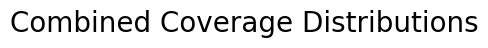

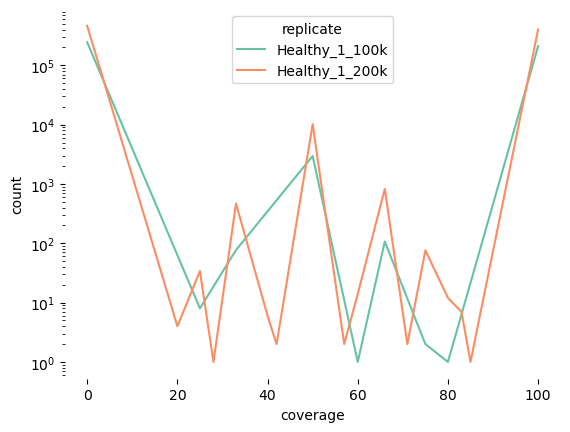

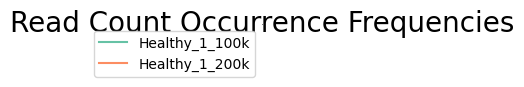

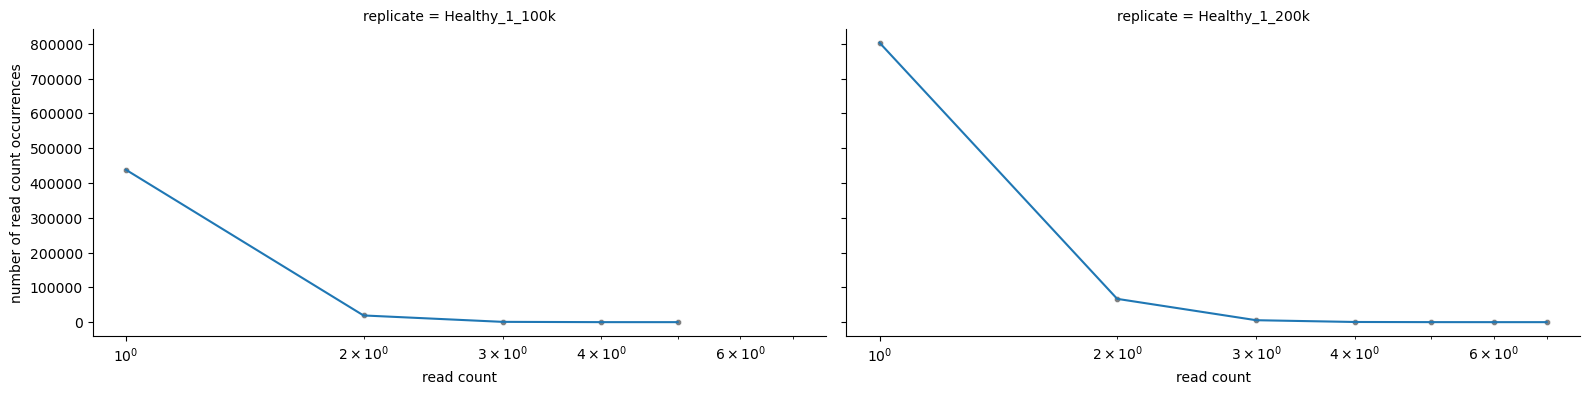

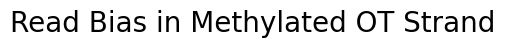

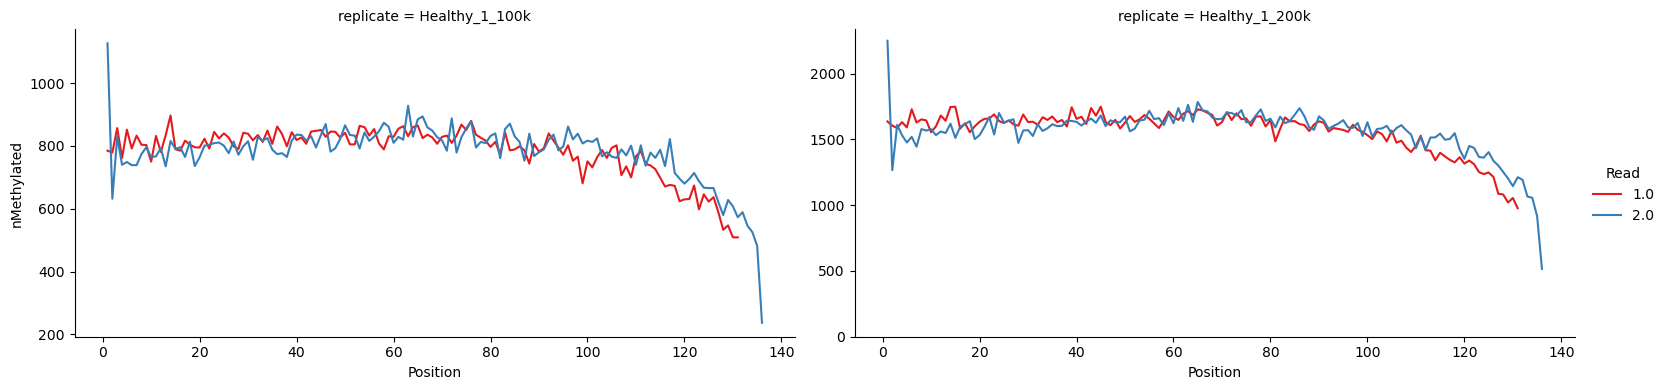

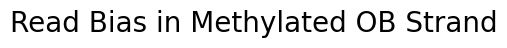

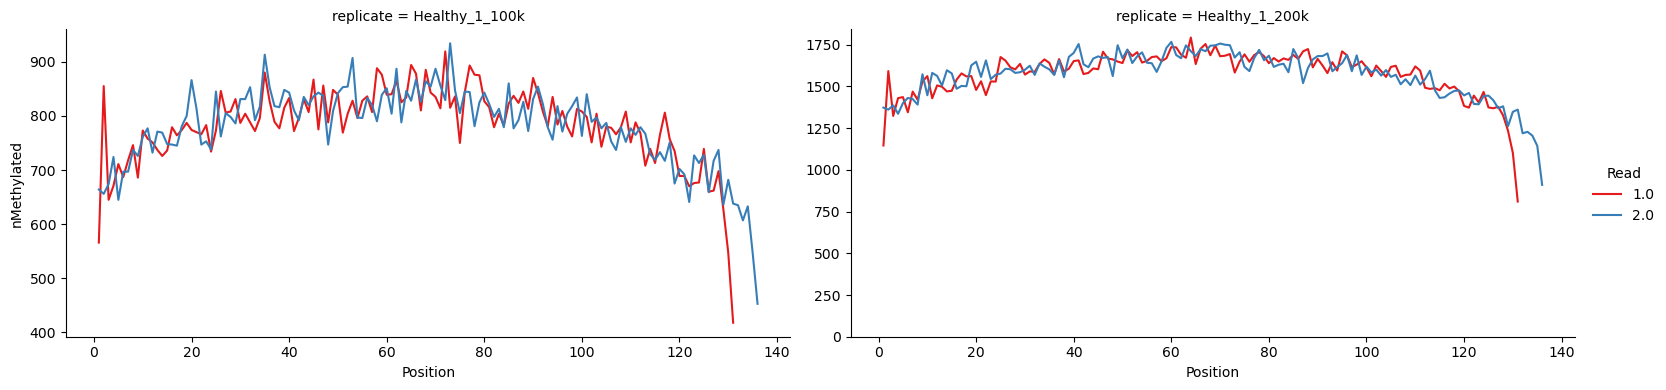

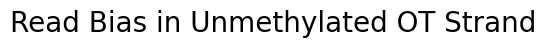

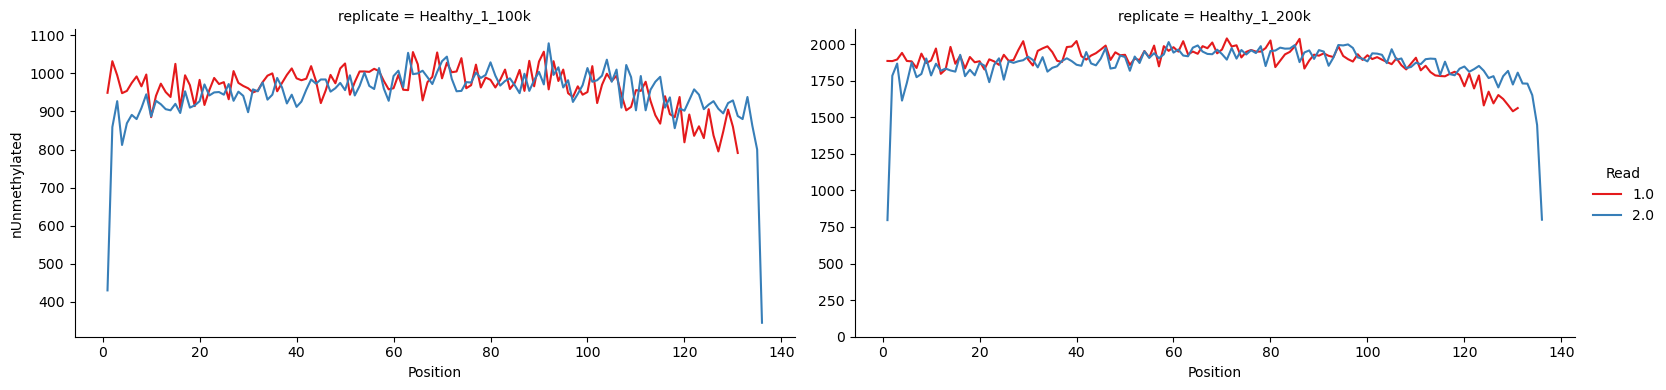

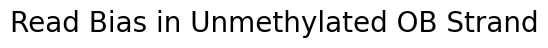

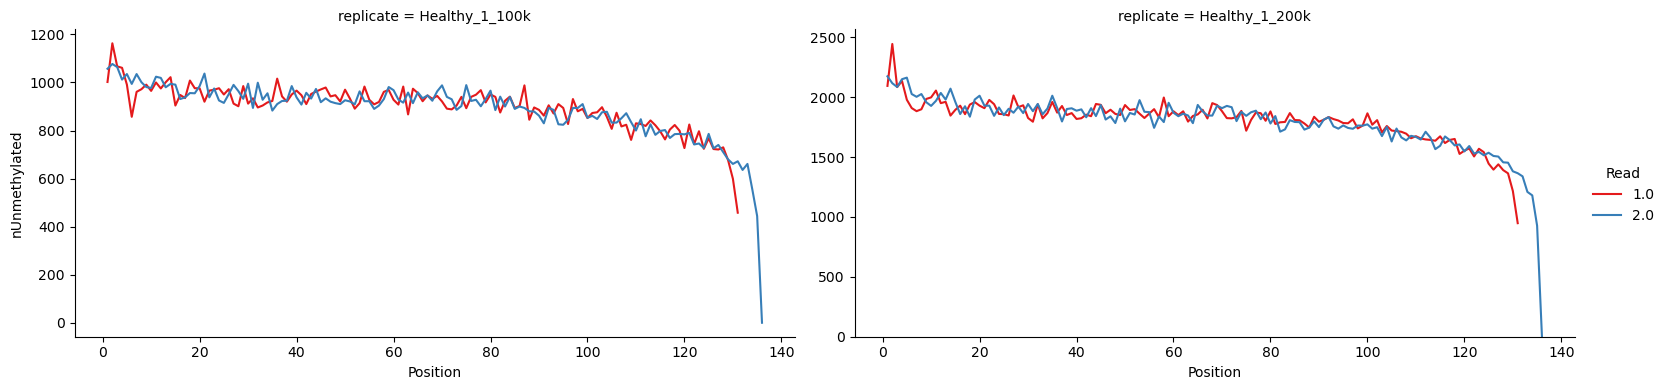

In [41]:
output_basic_read_statistics(rnf_counts_id_df,mbias_data_id_df,tab_id_value_counts_df,metrics_table)